# 0DTE nearest-OTM straddle, every 30-min bar

This notebook is **not** the paper 15:30→close trade
(`atm_straddle_rv_iv.ipynb`). It is one explicit choice of two
intraday extensions, spelled out before any table.

## Choice 1 — hold vs re-pick (instrument)

| | **Hold** (path of one straddle) | **Re-pick** (**this notebook**) |
|---|---|---|
| strikes | pick once, keep $K$ all day | new nearest-OTM at every 30-min bar $t$ |
| $R_t$ | 30-min mid path of **those** $K$; last bar cash-settles | next mid of the **$t$-straddle**; **15:30 cash-settles that straddle** |
| what it is | scalar expansion of one trade | a sequence of 30-min straddles |

**Proper $R_t$.** Pair the return with the forecast window.

- Re-pick + next-bar $\widehat{RV}_t$: $R_t =$ next mid of the straddle
  picked at $t$, divided by entry, minus 1 — a 30-min hold — for bars
  through 15:00. The **15:30** straddle cash-settles at the official
  close (the paper payoff): by decision, **no return in this trade uses
  a 16:00 quote**. The 16:00 stamp sits after the cash close — its
  quotes are carried-forward placeholders and its vendor implied
  volatility is entirely censored solver nodes (§3) — so the 16:00
  straddle is not built and the 15:30 exit is settlement, not the
  16:00 mid.

This notebook **re-picks**. It does not mark one straddle through the
day.

## No-peek protocol

Every position-forming quantity at bar $t$ is one of two things: the
bar's **own entry quote** (the tradable price at decision time), or
an estimate built **strictly from prior days, lagged at least one
day** — the smear's $(a,b,\hat\sigma^2)$, the diurnal profile $w$,
the per-clock leverage medians. Realized exits enter only as
outcomes, never as inputs. No quantity differences two quotes taken
at different times: that construction (the implied-decay $\Delta V$)
embeds the later quote's view of the bar it brackets, and is
confined to parked studies. By construction a perturbation of
day-$d$ inputs cannot move a day-$d$ estimate; it registers on day
$d{+}1$.

The construction was re-audited after the bar-end alignment fix (the
forecast panel is bar-end labelled, so trade bar $t$ joins the row
stamped $t{+}30$ min): perturbing the joined row's realized variance,
whole days and single rows, leaves every same-day position unchanged.
The join-shift diagnostic for the close trade, which places the fresh
join on a smooth staleness curve and shows the jump one bar of actual
lookahead produces, lives in the RV–IV notebook and is not repeated
here. Upstream, `baseline` is a strictly-prior-days per-clock
estimator and every forecast feature carries the one-bar shift.

## Choice 2 — IV (same window as $\widehat{RV}$)

$\widehat{RV}_t$ is next-**30-min** realized variance (smeared
one-bar-ahead $y$). Implied variance has to live on that same window.

| pairing | implied variance | forecast | when it is right |
|---|---|---|---|
| 30-min pairing (retired; a units check in §5) | $\mathrm{IV}_{30}^{2}=(\mathrm{IV}^{\mathrm{hr}})^{2}/2$ | next-bar $\widehat{RV}_t$ | only at 15:30, where the remaining window is 30 min |
| remaining-session VRP | $(\mathrm{IV}^{\mathrm{hr}})^{2}\cdot h_t$ with $h_t$ hours left | **remaining** RV, not next-bar $\widehat{RV}$ | hold to close |
| **window-matched** (this notebook, §5b) | $(\mathrm{IV}^{\mathrm{hr}})^{2}\cdot h_t\cdot w_t$, $w_t$ the next bar's share | next-bar $\widehat{RV}_t$ | every clock: both sides on the same 30-min window |

At **15:30** the remaining window **is** 30 min, so the two pairings
coincide — that is the paper. At **10:00** they do not: remaining
session is ~6 hours; next-bar $\widehat{RV}$ is 30 min. Using
$\mathrm{IV}^{2}/2$ at 10:00 is the 30-min pairing, **not**
remaining-session VRP.

Hourly IV of the two legs is $(\mathrm{IV}_c+\mathrm{IV}_p)/2$ — equal-weight
on the two contracts, same as the close trade.

## Choice 3 — 9:30

The cash session opens at 9:30. This tape has the 9:30 bar and **no**
vendor `underlying_price` (0% finite). `^GSPC` Open **is** the 9:30
cash print and can be $S_{9:30}$. Live mids at 9:30 exist on only
~40% of days (the §3 cell prints the 9:30 stamps with no live quote
at all), so a GSPC-Open ATM straddle would be a **sparse** extra bar,
not a full panel. The scored trade therefore starts at 10:00, where
the vendor $S$ is live, and the Open path is not built here:
`yfinance` enters only for settlement.

In [1]:
import os
import sys
from pathlib import Path
import matplotlib
matplotlib.use("module://matplotlib_inline.backend_inline")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
import yfinance as yf

sys.path.insert(0, str(Path.cwd() if (Path.cwd() / "atm_straddle_lib.py").exists() else Path.cwd() / "notebooks"))
import atm_straddle_lib as asl

REPO = asl.find_repo(Path.cwd())
OUT = REPO / "results" / "atm_straddle_intraday"
OUT.mkdir(parents=True, exist_ok=True)
CACHE = OUT / "cache"
CACHE.mkdir(parents=True, exist_ok=True)
print("repo:", REPO)
pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 20)
pd.set_option("display.float_format", lambda x: f"{x: .6f}")


repo: C:\Users\james\CC Allowed\harxhar-0dte-professor


## 1. Load the 0DTE chain (every 30-min bar)

In [2]:
CHAIN_CODE_HASH = "078e03be01"
TRADE_CODE_HASH = "f24191ffee"
# [cache:load]
import hashlib
import pyarrow.parquet as pq
path = REPO / "data" / "spxw_chain.parquet"
COLS = ["expiration", "timestamp", "strike", "cp", "bid", "ask", "mid",
        "underlying_price", "impl_volatility"]
opt = ["hours_to_expiration"]
_st = os.stat(path)
# Cache keys carry a hash of the construction cells' source (injected by
# the writer), so any change to the load/filter/pick/exit logic mints a
# new key and stale caches can never serve the new code. The trade key
# also carries the CONTENT hash of the settlement cache: every last bar
# settles against the official close, so a revised close changes those
# returns, and a key that named only the loader's source would go on
# serving the old ones.
_gspc_p = CACHE / "gspc_ohlc.parquet"


def _gspc_fp():
    if not _gspc_p.exists():
        return "nosettle"
    return hashlib.sha256(_gspc_p.read_bytes()).hexdigest()[:10]


def _trade_key():
    return CACHE / f"trade_{_st.st_size}_{_st.st_mtime_ns}_{TRADE_CODE_HASH}_{_gspc_fp()}.parquet"


_ck = CACHE / f"chain_0dte_{_st.st_size}_{_st.st_mtime_ns}_{CHAIN_CODE_HASH}.parquet"
_trade_ck = _trade_key()
print("settlement cache content hash in the trade key:", _gspc_fp())
if _trade_ck.exists():
    chain = None
    print("chain load skipped: trade cache hit (code-hashed key)")
elif _ck.exists():
    chain = pd.read_parquet(_ck)
    print("cache hit", _ck.name)
else:
    avail_cols = set(pq.ParquetFile(path).schema_arrow.names)
    keep_cols = [c for c in COLS + opt if c in avail_cols]
    raw = pd.read_parquet(path, columns=keep_cols)
    raw["timestamp"] = pd.to_datetime(raw["timestamp"], utc=True)
    raw["expiration"] = pd.to_datetime(raw["expiration"])
    raw["cp"] = raw["cp"].astype(str).str.upper().str[0]
    codes, uts = pd.factorize(raw["timestamp"])
    uet = pd.DatetimeIndex(uts).tz_convert("America/New_York")
    raw["et"] = uet.take(codes)
    raw["et_date"] = uet.normalize().take(codes)
    ecodes, uexp = pd.factorize(raw["expiration"])
    uexp_d = pd.DatetimeIndex(uexp).tz_localize("America/New_York", ambiguous="NaT", nonexistent="NaT").normalize()
    raw["exp_date"] = uexp_d.take(ecodes)
    raw["is_0dte"] = raw["et_date"] == raw["exp_date"]
    chain = raw[raw["is_0dte"]].copy()
    for old in CACHE.glob("chain_0dte_*.parquet"):
        old.unlink()
    chain.to_parquet(_ck)
if chain is not None:
    print("0DTE rows", f"{len(chain):,}")
    et0 = pd.to_datetime(chain["et"])
    print("clock times", sorted(et0.dt.strftime("%H:%M").unique()))
    print(chain.head(3))


settlement cache content hash in the trade key: 9d76153205
chain load skipped: trade cache hit (code-hashed key)


## 2. Regular hours; drop half-sessions

Twelve days in the file are half sessions: the cash market closed at
13:00 ET and the vendor carried the 13:00 quotes forward to a full
grid, so every stamp from 13:30 on is a frozen snapshot. A one-bar
hold between two frozen stamps records $R=0$ exactly — deflating the
pooled dispersion — and the last one settles against a close that was
already known at "entry". The chain says so itself:
`hours_to_expiration` is $\le 0$ at the 15:30 stamp on exactly those
days and on no other. That is the rule (`asl.early_close_days`),
shared with the close-trade notebook, and the dropped dates are
listed below. The days go whole; they are never re-pointed at the
13:00 bar, whose quotes are already the frozen snapshot while the
underlying print is older still.

In [3]:
# [cache:rth]
# The dropped dates are persisted beside the trade cache so this cell prints them
# whether or not the chain was reloaded: a cache hit must not hide the filter.
_ec_csv = CACHE / (_trade_ck.stem + "_early_close.csv")
if chain is None:
    print("filter applied when the cached trade was built; the dropped dates were persisted with it")
else:
    et = pd.to_datetime(chain["et"])
    mins = et.dt.hour * 60 + et.dt.minute
    rth = (mins >= 9 * 60 + 30) & (mins <= 16 * 60)
    chain = chain[rth].copy()
    if "hours_to_expiration" not in chain.columns:
        raise KeyError("chain has no hours_to_expiration: the half-session rule cannot be applied")
    # Shared rule (the deck applies the same one): hours_to_expiration <= 0 at the 15:30 stamp.
    chain, half = asl.drop_early_close(chain)
    pd.DataFrame({"date": [str(d.date()) for d in half]}).to_csv(_ec_csv, index=False)
    print("rows after RTH filter", f"{len(chain):,}", "days", chain["expiration"].nunique())
if _ec_csv.exists():
    _ec = pd.read_csv(_ec_csv)
    print("half-session days dropped (15:30 stamp already expired):", len(_ec))
    print("  ", ", ".join(_ec["date"].astype(str)))
else:
    print("no persisted half-session list beside this trade cache: delete it to rebuild")


filter applied when the cached trade was built; the dropped dates were persisted with it
half-session days dropped (15:30 stamp already expired): 12
   2020-11-27, 2020-12-24, 2021-11-26, 2022-11-25, 2023-07-03, 2023-11-24, 2024-07-03, 2024-11-29, 2024-12-24, 2025-07-03, 2025-11-28, 2025-12-24


## 2b. The scored trade starts at 10:00, not 9:30

Vendor `underlying_price` at 9:30 is **all NaN** — the picker has no
$S$ to choose $K_c\ge S$, $K_p\le S$, so no 9:30 straddle can be
formed. Quotes bind too: live 9:30 mids exist on only ~40% of
expiration days. The first bar with both a vendor spot and live mids
on every day is 10:00. `yfinance` is used only for **settlement**
(the official close).

In [4]:
# [cache:gspc]
def load_gspc_ohlc(days):
    days = pd.to_datetime(days)
    cp = CACHE / "gspc_ohlc.parquet"
    if cp.exists():
        ohlc = pd.read_parquet(cp)
        ohlc.index = pd.to_datetime(ohlc.index)
        if ohlc.index.min() <= pd.Timestamp(days.min()) and ohlc.index.max() >= pd.Timestamp(days.max()):
            return ohlc
    raw = yf.download(
        "^GSPC",
        start=pd.Timestamp(days.min()) - pd.Timedelta("7D"),
        end=pd.Timestamp(days.max()) + pd.Timedelta("7D"),
        auto_adjust=True, progress=False, threads=True,
    )
    op, cl = raw["Open"].squeeze(), raw["Close"].squeeze()
    if isinstance(op, pd.DataFrame):
        op = op.iloc[:, 0]
    if isinstance(cl, pd.DataFrame):
        cl = cl.iloc[:, 0]
    out = pd.DataFrame({"open": op.to_numpy(float), "close": cl.to_numpy(float)}, index=op.index)
    ix = pd.to_datetime(out.index)
    if getattr(ix, "tz", None) is not None:
        ix = ix.tz_convert("America/New_York").tz_localize(None)
    out.index = ix.normalize()
    out.to_parquet(cp)
    return out.astype(float)

print("settlement source: GSPC official close via load_gspc_ohlc (cached)")


settlement source: GSPC official close via load_gspc_ohlc (cached)


## 3. Nearest-OTM straddle at each 30-min bar (re-pick; vendor $S$ only)

At every stamp, among quotes with a live midpoint: the call is the
smallest strike $K_c\ge S$, the put the largest $K_p\le S$. Two data
defects are guarded here rather than absorbed into a price
(`asl.pick_nearest_otm_guarded`).

- **No-quote sentinel.** `bid == ask == 0` is the vendor's "no
  quote", not a zero price; the midpoint is NaN and the contract is
  not live (`asl.quote_mid`). One-sided rows (`bid == 0`, `ask > 0`)
  keep their half-spread midpoint.
- **Vendor outages.** A stamp that lists a handful of contracts
  instead of a few hundred, or whose nearest OTM leg is more than
  10 points from the spot, is not a market. SPX strikes are 5 apart
  near the money, so one missing strike is tolerated and more than
  one is an outage. Those cells are dropped, with the reason, and
  listed below — the alternative is a "straddle" whose put is
  hundreds of points out of the money and whose return is a fiction.

In [5]:
# [cache:pick]
# Both the refused cells and the quote-hygiene counts are persisted beside the trade
# cache, so a cache hit still prints the evidence rather than hiding it.
_cells_csv = CACHE / (_trade_ck.stem + "_refused_cells.csv")
_diag_csv = CACHE / (_trade_ck.stem + "_pick_diag.csv")
if _trade_ck.exists():
    pkg = pd.read_parquet(_trade_ck)
    live = None
    print("trade cache hit", _trade_ck.name, "straddles", len(pkg), "days", pkg["expiration"].nunique())
    print(pkg[["expiration", "timestamp", "S", "K_c", "K_p", "entry"]].head())
else:
    live = chain.assign(mid=asl.quote_mid(chain["bid"], chain["ask"]).to_numpy())
    n_sentinel = int((live["mid"].isna() & np.isfinite(pd.to_numeric(chain["bid"], errors="coerce"))).sum())
    live = live[np.isfinite(live["mid"]) & (live["mid"] > 0)].copy()
    spot = asl.stamp_spot(live, ["expiration", "timestamp"])
    # A stamp with no live quote at all cannot even be offered to the guards: it forms no
    # straddle and simply leaves a hole in that day's grid. 9:30 is sparse by construction.
    _dead = (pd.MultiIndex.from_frame(chain[["expiration", "timestamp"]].drop_duplicates())
             .difference(pd.MultiIndex.from_frame(live[["expiration", "timestamp"]].drop_duplicates())))
    _dead_et = pd.to_datetime(_dead.get_level_values(1), utc=True).tz_convert("America/New_York")
    _dead_rth = _dead_et[~((_dead_et.hour == 9) & (_dead_et.minute == 30))]
    pkg, dropped = asl.pick_nearest_otm_guarded(
        live[["expiration", "timestamp", "strike", "cp", "bid", "ask", "mid", "impl_volatility"]],
        spot, keys=("expiration", "timestamp"))
    _d = dropped.copy()
    _d["et"] = pd.to_datetime(_d["timestamp"], utc=True).dt.tz_convert("America/New_York")
    _d = pd.concat([_d, pd.DataFrame({"et": _dead_rth, "reason": "no_live_quote", "n_live": 0})],
                   ignore_index=True)
    _d.sort_values("et")[["et", "reason", "S", "K_c", "K_p", "gap", "n_live"]].to_csv(_cells_csv, index=False)
    pkg = asl.attach_iv_hourly_as_30min(pkg)
    n_iv_cens = int(pkg["iv_hourly"].isna().sum() - pkg[["impl_volatility_c", "impl_volatility_p"]].isna().any(axis=1).sum())
    pd.Series({
        "no-quote rows held out of the live frame (bid == ask == 0)": n_sentinel,
        "stamps with live quotes": int(live.groupby(["expiration", "timestamp"]).ngroups),
        "of which with a vendor spot (the rest are 9:30)": len(spot),
        "stamps with no live quote at all": len(_dead_et),
        "of them at 9:30 (sparse by construction)": len(_dead_et) - len(_dead_rth),
        "straddles with a censored vendor implied volatility": n_iv_cens,
    }, name="count").to_csv(_diag_csv)
    pkg = pkg.sort_values(["expiration", "timestamp"]).reset_index(drop=True)
    print("straddles", len(pkg), "days", pkg["expiration"].nunique())
    print(pkg[["expiration", "timestamp", "S", "K_c", "K_p", "entry"]].head())
if _diag_csv.exists() and _cells_csv.exists():
    print(pd.read_csv(_diag_csv, index_col=0)["count"].to_string())
    _cells = pd.read_csv(_cells_csv)
    print("cells refused by the outage guards or with no live quote:", len(_cells))
    print(_cells["reason"].value_counts().to_string())
    print(_cells.to_string(index=False))
else:
    print("no persisted pick diagnostics beside this trade cache: delete it to rebuild")


trade cache hit trade_77439812_1786671584951439500_f24191ffee_9d76153205.parquet straddles 15343 days 1279
  expiration                 timestamp            S          K_c          K_p      entry
0 2020-01-03 2020-01-03 15:00:00+00:00  3237.649902  3240.000000  3235.000000  10.750000
1 2020-01-03 2020-01-03 15:30:00+00:00  3237.679932  3240.000000  3235.000000   8.650000
2 2020-01-03 2020-01-03 16:00:00+00:00  3234.679932  3235.000000  3230.000000   8.900000
3 2020-01-03 2020-01-03 16:30:00+00:00  3236.000000  3240.000000  3235.000000   7.100000
4 2020-01-03 2020-01-03 17:00:00+00:00  3241.270020  3245.000000  3240.000000   5.625000
no-quote rows held out of the live frame (bid == ask == 0)    297768
stamps with live quotes                                        17145
of which with a vendor spot (the rest are 9:30)                16626
stamps with no live quote at all                                 761
of them at 9:30 (sparse by construction)                         760
straddles with

## 4. Exit: next-bar mid; the 15:30 bar cash-settles

Re-pick 30-min hold: $R_t = \mathrm{exit}_{t+1}/P_t - 1$ with
$\mathrm{exit}_{t+1}$ = next mid of **those** $K$, for bars
10:00–15:00. If a leg is missing at $t+1$, the row is dropped —
counts printed below.

**15:30 / last bar** cash-settles vs `^GSPC` close — the paper
payoff on the 15:30 straddle.

In [6]:
# [cache:exit]
if "R" in pkg.columns and _trade_ck.exists():
    print("trade cache: skip exit rebuild")
    n_pkg = len(pkg)
else:
    et_pick = pd.to_datetime(pkg["timestamp"], utc=True).dt.tz_convert("America/New_York")
    is_1600 = (et_pick.dt.hour == 16) & (et_pick.dt.minute == 0)
    print("dropped", int(is_1600.sum()), "16:00 straddles (entry would be a 16:00 quote; excluded by decision)")
    pkg = pkg[~is_1600].copy()
    pkg["nxt_ts"] = pkg.groupby("expiration")["timestamp"].shift(-1)
    pkg["is_last"] = pkg["nxt_ts"].isna()
    days = pd.to_datetime(pkg["expiration"])
    if getattr(days.dt, "tz", None) is not None:
        days = days.dt.tz_convert("America/New_York").dt.tz_localize(None)
    days = days.dt.normalize()
    ohlc = load_gspc_ohlc(days)
    pkg["S_close"] = days.map(ohlc["close"])
    pkg["exit_settle"] = np.maximum(pkg["S_close"] - pkg["K_c"], 0.0) + np.maximum(pkg["K_p"] - pkg["S_close"], 0.0)
    nxt = pkg.loc[~pkg["is_last"], ["expiration", "nxt_ts", "K_c", "K_p"]].copy()
    left_c = nxt[["expiration", "nxt_ts", "K_c"]].rename(columns={"nxt_ts": "timestamp", "K_c": "strike"})
    left_p = nxt[["expiration", "nxt_ts", "K_p"]].rename(columns={"nxt_ts": "timestamp", "K_p": "strike"})
    quotes = live.loc[:, ["expiration", "timestamp", "strike", "cp", "bid", "ask", "mid"]]
    got_c = left_c.merge(quotes.loc[quotes["cp"] == "C", ["expiration", "timestamp", "strike", "bid", "ask", "mid"]],
                         on=["expiration", "timestamp", "strike"], how="left")
    got_p = left_p.merge(quotes.loc[quotes["cp"] == "P", ["expiration", "timestamp", "strike", "bid", "ask", "mid"]],
                         on=["expiration", "timestamp", "strike"], how="left")
    for _fld in ("mid", "bid", "ask"):   # next-bar quotes of the same strikes, persisted for the crossed-spread block
        nxt[f"{_fld}_c_nxt"] = got_c[_fld].to_numpy(dtype=float)
        nxt[f"{_fld}_p_nxt"] = got_p[_fld].to_numpy(dtype=float)
    pkg = pkg.merge(nxt[["expiration", "nxt_ts", "K_c", "K_p", "mid_c_nxt", "mid_p_nxt",
                         "bid_c_nxt", "bid_p_nxt", "ask_c_nxt", "ask_p_nxt"]],
                    on=["expiration", "nxt_ts", "K_c", "K_p"], how="left")
    pkg["exit_mark"] = pkg["mid_c_nxt"] + pkg["mid_p_nxt"]
    n_pkg = len(pkg)
n_last = int(pkg["is_last"].sum())
n_nonlast = n_pkg - n_last
miss_c = (~pkg["is_last"]) & pkg["mid_c_nxt"].isna()
miss_p = (~pkg["is_last"]) & pkg["mid_p_nxt"].isna()
miss_either = (~pkg["is_last"]) & ~np.isfinite(pkg["exit_mark"])
miss_settle = pkg["is_last"] & ~np.isfinite(pkg["exit_settle"])
bad_entry = ~np.isfinite(pkg["entry"]) | (pkg["entry"] <= 0)
print("straddles before exit filter", n_pkg)
print("last bar = 15:30 (cash-settle vs official close)", n_last)
print("non-last (next-mid path)", n_nonlast)
print("non-last missing next CALL mid", int(miss_c.sum()))
print("non-last missing next PUT mid", int(miss_p.sum()))
print("non-last missing either leg (row would drop)", int(miss_either.sum()),
      f"({100.0 * miss_either.sum() / max(n_nonlast, 1):.2f}% of non-last)")
print("last-bar missing GSPC settle", int(miss_settle.sum()))
print("bad entry (nonfinite or <=0)", int(bad_entry.sum()))

pkg["exit"] = np.where(pkg["is_last"], pkg["exit_settle"], pkg["exit_mark"])
keep = np.isfinite(pkg["entry"]) & np.isfinite(pkg["exit"]) & (pkg["entry"] > 0)
print("dropped at exit filter", int((~keep).sum()), "kept", int(keep.sum()))
pkg = pkg[keep].copy()
pkg["R"] = pkg["exit"] / pkg["entry"] - 1.0
pkg["R_as"] = -pkg["R"]
pkg["et"] = pd.to_datetime(pkg["timestamp"], utc=True).dt.tz_convert("America/New_York")
pkg["hour"] = pkg["et"].dt.hour
pkg["hhmm"] = pkg["et"].dt.strftime("%H:%M")
pkg["date"] = pkg["et"].dt.normalize().dt.tz_localize(None)
if not _trade_ck.exists():
    # The settlement cache is on disk now (this cell downloaded it if it was missing),
    # so re-mint the key with its content hash and carry the sidecars to the new stem.
    _stem0 = _trade_ck.stem
    _trade_ck = _trade_key()
    if _trade_ck.stem != _stem0:
        for _sc in CACHE.glob(_stem0 + "_*.csv"):
            _sc.rename(CACHE / _sc.name.replace(_stem0, _trade_ck.stem, 1))
        print("settlement cache was written during this run; trade key re-minted:", _trade_ck.name)
    for _old in CACHE.glob("trade_*"):       # stale caches and their diagnostic sidecars
        if not _old.name.startswith(_trade_ck.stem):
            _old.unlink()
    pkg.to_parquet(_trade_ck)
    print("wrote trade cache", _trade_ck.name)
print("bars with a return", len(pkg), "last-bar fraction", float(pkg["is_last"].mean()))
print("always-short R by clock time (no model; long R is the negative)")
as_raw = pkg.groupby("hhmm")["R_as"].agg(["count", "mean", "std", "median"])
as_raw["t"] = as_raw["mean"] / as_raw["std"] * np.sqrt(as_raw["count"])
as_raw["Sharpe_ann"] = as_raw["mean"] / as_raw["std"] * np.sqrt(asl.PERIODS_PER_YEAR)
print(as_raw.to_string())


trade cache: skip exit rebuild
straddles before exit filter 15343
last bar = 15:30 (cash-settle vs official close) 1279
non-last (next-mid path) 14064
non-last missing next CALL mid 0
non-last missing next PUT mid 0
non-last missing either leg (row would drop) 0 (0.00% of non-last)
last-bar missing GSPC settle 0
bad entry (nonfinite or <=0) 0
dropped at exit filter 0 kept 15343


bars with a return 15343 last-bar fraction 0.08336049012579026
always-short R by clock time (no model; long R is the negative)
       count      mean       std    median         t  Sharpe_ann
hhmm                                                            
10:00   1277  0.007205  0.151417  0.048701  1.700493    0.755405
10:30   1278  0.007297  0.148263  0.045593  1.759407    0.781270
11:00   1278  0.001557  0.135726  0.037640  0.410215    0.182157
11:30   1278  0.011395  0.121808  0.043083  3.344363    1.485074
12:00   1279  0.006863  0.123748  0.037344  1.983404    0.880392
12:30   1279  0.006968  0.125388  0.035644  1.987380    0.882157
13:00   1279  0.007116  0.196838  0.052469  1.292858    0.573873
13:30   1279  0.012318  0.174841  0.059880  2.519539    1.118372
14:00   1279  0.006572  0.252436  0.077369  0.931090    0.413292
14:30   1279  0.026143  0.294782  0.099071  3.171669    1.407839
15:00   1279  0.058902  0.347565  0.159170  6.060816    2.690272
15:30   1279  0.024562  1.12

## Side question: vendor IV units (Chris hourly)

The chain column is `impl_volatility` (exported as `new_implied_vol`).
OptionMetrics' **manual** says that field is an **annualized** Black–Scholes
vol: ATM SPX should be on the order of $0.20$ ($20\%$). A 30-minute
variance from that reading would be

$$
\sigma_{\mathrm{ann}}^{2}\times\frac{0.5}{252\times 6.5}
\sim 0.04\times 3\times 10^{-4}
\sim 10^{-5}\text{--}10^{-6}
$$

if the $0.20$ were real.

**What is in the file** is a couple of thousandths at ATM — the cell
below prints the median, $0.0025$ — not $0.20$: two orders of
magnitude too small to be annualized vol. A $0.25\%$ annualized vol
cannot price the $\sim\$13$ ATM straddle whose median the same cell
prints; those mids are $\sim 20\%$ vol.
That size mismatch is the unit tell.

Read the number as a **1-hour standard deviation** of returns (Chris:
"hourly vol") and the scale matches $\widehat{RV}$:

$$
\mathrm{Var}(1\mathrm{h})=0.0025^{2}=6.3\times 10^{-6},\qquad
\mathrm{Var}(30\mathrm{min})=\tfrac12\times 6.3\times 10^{-6}
=3.2\times 10^{-6},
$$

which are the `already_window` and `chris_hourly` medians the cell
prints. Median $\widehat{RV}$ here is $\sim 3.3\times 10^{-6}$: the
same size. Treat the vendor number as
OM-annualized and shrink by $1/(252\times 6.5)$ and you get
$\sim 10^{-9}$ (`annualized_om` below) — not comparable to
$\widehat{RV}$. We do not use that.

Hence $\mathrm{IV}_{30}=\mathrm{IV}^{\mathrm{hr}}/\sqrt{2}$ and
$\mathrm{iv\_var}=(\mathrm{IV}^{\mathrm{hr}})^{2}/2$. No inversion from
the mid. Other scripts in the repo ignore the vendor number and invert
BS with $\tau=h_{\mathrm{close}}/(252\times 6.5)$; that is a different
convention.

For the **30-min hold** pairing this notebook uses
$\mathrm{iv\_var}=(\mathrm{IV}^{\mathrm{hr}})^{2}\cdot 0.5$ at every
bar — the same window as next-bar $\widehat{RV}$. That is
remaining-session variance **only** at 15:30, where 30 minutes is what
is left.

In [7]:
iv = pkg["iv_hourly"].astype(float)
print("median vendor IV", float(iv.median()), "median straddle mid", float(pkg["entry"].median()))
conv = asl.iv_var_from_conventions(iv, hours_remaining=0.5)
for k, s in conv.items():
    print(k, "median var", float(s.median()))
print("30-min pairing: iv_var = (IV_hr)^2 * 0.5  [used]")
print("remaining-session pairing would need hours_left * (IV_hr)^2 and remaining RV [not used]")


median vendor IV 0.0025142739759758115 median straddle mid 13.350000143051147
chris_hourly median var 3.160786829816149e-06
annualized_om median var 1.929662289265048e-09
already_window median var 6.321573659632298e-06
30-min pairing: iv_var = (IV_hr)^2 * 0.5  [used]
remaining-session pairing would need hours_left * (IV_hr)^2 and remaining RV [not used]


## 5. Forecasts and the smear (same map as the close trade)

The close trade and this notebook share `second_order_raw` /
`load_yhat_panel`:

1. Forecasts live on $y=\sqrt{RV/B}$. Actual $y$ on each bar:
   $\sqrt{\mathrm{rv\_raw}/B}$.
2. **Only regular-session bars enter the fit** (rows labelled
   10:30–16:00, the bars 10:00–15:30), and the mask goes further: a
   date is in the fit only if the panel carries a stamp-16:00 row for
   it, and dates on the 2001–2025 NYSE 13:00 early-close calendar are
   excluded whole. Off-session bars, the futures-only bars printed on
   NYSE holidays, and the post-close half-session bars are all
   mispredicted by orders of magnitude and would pollute the
   calibration. The cell prints the surviving fit-row count and how
   many panel rows fall on early-close dates.
3. Sessions are counted on those fit rows, so for evaluation session
   $d\ge 63$ the window is the **250 trading sessions strictly before
   $d$** — prior days only; same-day bars are not in the window. The
   fit is weighted least
   squares with weights $1/\max(\widehat{y},q_{10})^{2}$, $q_{10}$ the
   window's tenth percentile of $\widehat{y}$ (the variance-stabilizing
   weighting under multiplicative errors), solved one session at a
   time.
4. Fit $m=a+b\,\widehat{y}$ and the weighted residual variance
   $\hat\sigma^{2}$ on that window. Apply **that session's**
   $(a,b,\hat\sigma^{2})$ to **each** bar $t$ of day $d$:
   $\widehat{RV}_t=(m_t^{2}+\hat\sigma^{2}_d)B_t$. The §5b cell prints
   the resulting calibration by year.

The close-trade notebook runs this on the full panel, then **keeps the 15:30
row**. This notebook keeps every row. Coefficients $(a_d,b_d,\hat\sigma^{2}_d)$
are the same object. What changes is which $t$ you score, not how the
smear is fit.

$\widehat{RV}_t$ is $E[RV]$ for the **next 30-min bar**, not remaining
session.

**Alignment.** Panel stamps are **bar-end labelled**: the row at
stamp $\tau$ carries the realized variance of $[\tau-30,\tau]$ and
the forecast of that same bar, issued at $\tau-30$ (the RV–IV
notebook measures the lead–lag peak correlation at one bar and the
same-row MZ slope near one). A trade entered at
$t$ therefore pairs with the **stamp $t{+}30$ row** — the forecast
issued at $t$ for the bar actually held — and that row's realized
variance is the bar's own. Earlier versions paired stamp $t$ with
trade $t$: causal (a *stale* forecast, the opposite of lookahead)
but one bar behind, and it shifted every per-clock realized
attribution by one row. The loader marks every row it actually fit
(`in_fit`); the cell asserts that every joined trade bar is one of
them, which is the alignment check in one line.

**When there is no signal.** A bar keeps its return whenever the
forecast panel has a row for it. Two things can still leave it
without a *signal*: the vendor's implied volatility on either leg is
a censored solver node (§3), or the diurnal profile is still in its
warm-up (§5b). Such bars sit flat ($q=0$) in the rules that use the
forecast and are unaffected in the rules that do not, so every rule
in §6 is scored on the same bars. Only bars with no forecast row at
all are dropped.

In [8]:
YHATS = asl.yhat_paths(REPO)
LABEL = asl.YHAT_LABEL
panels = {}
_blk2 = YHATS["blk2"]
if not _blk2.exists():
    print("missing", _blk2)
else:
    df = asl.load_yhat_panel(_blk2)
    panels["blk2"] = df.set_index("t")[["rv_hat", "yhat", "rv_raw", "baseline", "in_fit", "early_close"]]
    print(LABEL["blk2"] + " panel: bars", len(panels["blk2"]),
          "| in the MZ fit", int(df["in_fit"].sum()),
          "| rows on early-close dates (no forecast issued)", int(df["early_close"].sum()))

pkg["t"] = pd.to_datetime(pkg["timestamp"], utc=True)
work = pkg.copy()
if "blk2" in panels:
    # Bar-end-labelled panel: stamp t+30 carries the forecast issued AT t
    # for the bar [t, t+30] being held, and that bar's own realized
    # variance. Shift the panel stamps back one bar so trade bar t joins
    # its fresh forecast and its own realized.
    _p = panels["blk2"].reset_index()
    _p["t"] = pd.to_datetime(_p["t"], utc=True) - pd.Timedelta(minutes=30)
    work = work.merge(_p, on="t", how="left")
work["iv_var_chris"] = (work["iv_hourly"].astype(float) ** 2) * 0.5
work["iv_var_om"] = (work["iv_hourly"].astype(float) ** 2) * 0.5 / (252.0 * 6.5)
work["iv_var_raw"] = work["iv_hourly"].astype(float) ** 2
print("median rv_hat", float(pd.to_numeric(work.get("rv_hat", pd.Series(dtype=float)), errors="coerce").median()))
print("median iv_var chris / om / raw",
      float(work["iv_var_chris"].median()),
      float(work["iv_var_om"].median()),
      float(work["iv_var_raw"].median()))
print("the 30-min pairing above is a units check; every rule uses the window-matched signal of the next section")
n_pre = len(work)
work["signal"] = work["rv_hat"] - work["iv_var_chris"]
work = work.dropna(subset=["R", "rv_hat"])
print("dropped at forecast join (no forecast row for the bar)", n_pre - len(work), "kept", len(work))
# Alignment check in one line: the trade bars 10:00-15:30 join stamps 10:30-16:00, which is
# exactly the loader's session fit mask, so every joined row must be one the smear was fit on.
assert bool(work["in_fit"].all()), "a joined trade bar is outside the smear's fit mask"
print("every joined bar is inside the smear's session fit mask (in_fit)")
print("bars kept with no vendor implied volatility (censored solver node -> flat in the sign(s) rules):",
      int(work["iv_hourly"].isna().sum()))
print("last scored bar is 15:30, cash-settled at the official close (paper payoff); no 16:00 quotes anywhere")
print("bars after join", len(work), "clock times", sorted(work["hhmm"].unique()))


block-diagonal ridge panel: bars 276317 | in the MZ fit 68215 | rows on early-close dates (no forecast issued) 1684
median rv_hat 3.3418130670513306e-06
median iv_var chris / om / raw 3.160786829816149e-06 1.929662289265048e-09 6.321573659632298e-06
the 30-min pairing above is a units check; every rule uses the window-matched signal of the next section
dropped at forecast join (no forecast row for the bar) 4956 kept 10387
every joined bar is inside the smear's session fit mask (in_fit)
bars kept with no vendor implied volatility (censored solver node -> flat in the sign(s) rules): 13
last scored bar is 15:30, cash-settled at the official close (paper payoff); no 16:00 quotes anywhere
bars after join 10387 clock times ['10:00', '10:30', '11:00', '11:30', '12:00', '12:30', '13:00', '13:30', '14:00', '14:30', '15:00', '15:30']


## 5b. Window-matched signal and forecast calibration

One construction plus one verification, both causal, feeding extra
rows of the §6 table.

**Forecast calibration (the fit-set fix).** The smear previously fit
its MZ regression on every 30-min bar of the day, overnight included;
off-session bars are mispredicted by orders of magnitude and pulled
the calibration off the session bars it is actually used on.
The fix lives in the lib: `second_order_raw` fits only the scored
session bars (10:00–15:30) on the trailing window of 250 sessions.
The cell below prints the mean ratio $\widehat{RV}/RV$ on the scored
bars by year and pooled; the pooled ratio of means is dominated by
2020's variance, so the per-year view is the one to read. No debias
layer sits on top — the cell only verifies calibration.

**Resliced implied (window-matched signal).** One option prices only
the integral of variance to the close; the vendor hourly IV is that
integral per hour. To compare against a *next-30-min* forecast,
reslice: $\mathrm{IV}^{2}_{\mathrm{hr}}\times h_t$ is the remaining
implied variance ($h_t$ = hours to close), and the next bar's share
is $w_t$ = this clock's fraction of remaining realized variance,
estimated from the **expanding per-clock mean** of realized bar
variance on prior days only. Then

$$s^{\mathrm{m}}_t=\widehat{RV}_t-\mathrm{IV}^{2}_{\mathrm{hr}}\,h_t\,w_t.$$

At 15:30, $w=1$, $h=\tfrac12$: the matched implied collapses to the
paper's $\mathrm{IV}^2/2$ exactly (checked in-cell). Warm-up rows —
the profile needs 63 prior sessions, and the cell prints how many
dates that covers — carry no matched signal and sit flat, $q=0$, in
the $\mathrm{sign}(s)$ rules, as do the bars whose vendor implied
volatility was censored (§3). Those zeros stay in the daily sums.

In [9]:
# The fit-set fix lives in asl.second_order_raw (session-only MZ fit).
# Verify calibration on the scored panel per year and pooled: the pooled
# ratio of means is dominated by 2020's variance, so read the per-year view.
ok = np.isfinite(work["rv_hat"]) & np.isfinite(work["rv_raw"])
_cal = work.loc[ok].groupby(work.loc[ok, "date"].dt.year).apply(
    lambda g: float(g["rv_hat"].mean() / g["rv_raw"].mean()), include_groups=False
)
print("mean rv_hat/rv_raw by year, session-fit smear:")
print(_cal.round(3).to_string())
print("pooled", round(float(work.loc[ok, "rv_hat"].mean() / work.loc[ok, "rv_raw"].mean()), 3),
      "- the pooled ratio of means is dominated by 2020, so read the per-year view")

# Causal diurnal profile: expanding per-clock mean of realized bar variance,
# prior days only; w = this clock's share of the remaining-session sum.
prof = work.pivot_table(index="date", columns="hhmm", values="rv_raw", aggfunc="mean").sort_index()
prof_exp = prof.expanding(min_periods=63).mean().shift(1)
clocks = sorted(work["hhmm"].unique())
rem_sum = prof_exp[clocks[::-1]].cumsum(axis=1)[clocks]
w_slice = prof_exp / rem_sum
mi = pd.MultiIndex.from_arrays([work["date"], work["hhmm"]])
work["w_slice"] = w_slice.stack().reindex(mi).to_numpy()
n_rem = {c: len(clocks) - i for i, c in enumerate(clocks)}
work["h_rem"] = work["hhmm"].map(n_rem).astype(float) * 0.5
work["iv_next30_matched"] = work["iv_var_raw"] * work["h_rem"] * work["w_slice"]
work["s_matched"] = work["rv_hat"] - work["iv_next30_matched"]

chk = work[(work["hhmm"] == "15:30") & np.isfinite(work["iv_next30_matched"])]
print("15:30 collapse check: median |matched/chris - 1| =",
      float((chk["iv_next30_matched"] / chk["iv_var_chris"] - 1.0).abs().median()))
mvalid = work[np.isfinite(work["s_matched"])]
_no_sig = work.loc[~np.isfinite(work["s_matched"])]
_warm = _no_sig.loc[~np.isfinite(_no_sig["w_slice"]), "date"].nunique()
_cens = int((np.isfinite(_no_sig["w_slice"]) & ~np.isfinite(_no_sig["iv_var_raw"])).sum())
print("matched-signal rows", len(mvalid), "/", len(work),
      "| flat for warm-up:", int((~np.isfinite(work["w_slice"])).sum()), "bars on", _warm, "dates",
      "| flat for a censored implied volatility:", _cens, "bars")
print("pct s_matched>0 by clock")
print(mvalid.groupby("hhmm")["s_matched"].apply(lambda x: 100.0 * float((x > 0).mean())).round(1).to_string())

# Remaining-session pairing (option 1), kept for reference. Same sign as
# s_matched when the forecast follows the profile (s_rem = s_matched / w),
# so the sign(s) portfolio is identical:
# rvhat_rem = work["rv_hat"] / work["w_slice"]
# iv_rem = work["iv_var_raw"] * work["h_rem"]
# work["s_rem"] = rvhat_rem - iv_rem


mean rv_hat/rv_raw by year, session-fit smear:
date
2020    1.243000
2021    0.996000
2022    1.013000
2023    1.008000
2024    1.045000
pooled 1.101 - the pooled ratio of means is dominated by 2020, so read the per-year view


15:30 collapse check: median |matched/chris - 1| = 0.0
matched-signal rows 9630 / 10387 | flat for warm-up: 756 bars on 64 dates | flat for a censored implied volatility: 1 bars
pct s_matched>0 by clock
hhmm
10:00    61.900000
10:30    60.000000
11:00    60.700000
11:30    50.200000
12:00    62.500000
12:30    57.800000
13:00    67.600000
13:30    46.900000
14:00    67.600000
14:30    52.300000
15:00    51.600000
15:30    38.100000


## 6. Rule table (pooled)

Same bars and the same long-straddle $R$ (next-mid 30-min holds
10:00–15:00; the 15:30 leg cash-settles at the official close — the
paper payoff; no 16:00 quotes anywhere, see §4). Only the position
$q_t$ changes. One forecast: the block-diagonal ridge. Mid fill.

**Rules** (each returns $R'_t=q_t R_t$). Every rule below that uses
a forecast uses the §5b window-matched signal
$s^{\mathrm{m}}_t=\widehat{RV}_t-\mathrm{IV}^{2}_{\mathrm{hr}}h_t\,w_t$
— the only pairing whose two sides live on the same window at every
clock. An earlier version of the $\mathrm{sign}(s)$ row used
the 30-min pairing; those are **retired**: that signal compared a
next-bar forecast to a remaining-session-average implied, so away
from 15:30 it detected the diurnal profile, not mispricing (§5b).

- **always short:** $q_t\equiv -1$ every bar. No forecast. This is
  the scalar: short every re-picked straddle.
- **always short, flat at 15:30:** $q_t=-1$ on every bar before 15:30
  and $q_t=0$ on the 15:30 bar. No forecast. It drops the settlement
  leg — the one bar that carries most of the day's variance — and is
  the forecast-free control the hybrid has to clear.
- **$\mathrm{sign}(s)$:** $q_t=\mathrm{sign}(s^{\mathrm{m}}_t)$ —
  long the straddle when the matched forecast exceeds the matched
  implied slice, short otherwise; bars with no signal — warm-up, or a
  censored implied volatility — sit flat ($q=0$), and those zeros
  stay in the daily sums, so the row's Sharpe is over all days, not
  over active days only.
- **always short, $\mathrm{sign}(s)$ close:** $q_t=-1$ on every bar
  before 15:30 and $q_t=\mathrm{sign}(s^{\mathrm{m}}_t)$ on the 15:30
  bar — always short on every intraday bar, with the settlement leg
  sized by the forecast's sign. The next section reads it against the
  two forecast-free rules, at the midpoint and at the crossed spread;
  the two fills do not agree.

The table is **pooled**: every clock stacked into one list (the row
count is the `n` column). Those are the twelve bars **of the same
day**, not that many separate days; the cell prints the days that
have fewer than twelve bars.

**How pooled `Sharpe_ann` is computed**

1. For each bar, $R'_t=q_t R_t$ as above.
2. For each calendar day $d$, add the day's bars (non-compounded):
   $R^{day}_d=\sum_{t\in d} R'_t$. One number per expiration day
   (`n_days`).
3. $\mathrm{Sharpe}_{ann}=\overline{R}^{day}/\mathrm{sd}(R^{day})\times\sqrt{252}$.

Not $\overline{R'}/\mathrm{sd}(R')\times\sqrt{252}$ on the stacked
bars (that treats each 30-min row as a full trading day). Not that
quantity times $\sqrt{12}$ (the twelve bars on one day are not
twelve independent days). Daily collapse is the conversion that
respects same-day dependence. $\sqrt{252}$ is then the same
year-length as the 15:30 paper trade.

**Columns.** `mean` through `ex_kurt` are `Series.describe`-style
moments of the **30-min** $R'$ (unannualized). The rest:

- `n` — 30-min bars scored.
- `n_days` — expiration days after the daily sum.
- `mean` — mean 30-min $R'$.
- `mean_daily` — mean of $R^{day}$.
- `std`, `min`, `25%`, `50%`, `75%`, `max` — of 30-min $R'$.
- `skew`, `ex_kurt` — of 30-min $R'$. `ex_kurt` is **excess**
  kurtosis (Fisher; pandas `Series.kurt()`): fourth standardized
  moment minus 3, so a Gaussian scores 0 not 3. Raw (Pearson)
  kurtosis is `ex_kurt + 3`.
- `Sharpe_bar` — $\overline{R'}/\mathrm{sd}(R')$ on the stacked
  30-min rows. No $\sqrt{\,\cdot\,}$. Typical 30-min trade, not
  annual.
- `Sharpe_ann` — annualized Sharpe of the **daily** $R^{day}$
  series, as in the three steps above.
- `t_mean` — $t$-stat of that daily mean,
  $t=\sqrt{n_{\mathrm{days}}}\cdot\overline{R}^{day}/\mathrm{sd}(R^{day})$.
  Uses the raw mean/std, not an extra annualization.
  $t=\mathrm{Sharpe}_{ann}\times\sqrt{n_{\mathrm{days}}/252}$ at
  fixed $n_{\mathrm{days}}$; both are shown so the table reads
  either way.
- `n_buy` / `pct_buy` — bars with $q_t>0$ (buy the straddle).
  Always-short is 0 by construction.

The 16:00 straddle never enters the trade (§4): bars are 10:00–15:00
next-mid holds plus the 15:30 settlement leg — the paper payoff.
Split by clock is §8.

In [10]:
work = work.sort_values("t").reset_index(drop=True)
pos_m = pd.Series(np.where(work["s_matched"] > 0, 1.0, -1.0), index=work.index).where(
    np.isfinite(work["s_matched"])
)
q = {
    "always short": pd.Series(-1.0, index=work.index),
    "always short, flat at 15:30": pd.Series(
        np.where(work["hhmm"] == "15:30", 0.0, -1.0), index=work.index
    ),
    "sign(s)": pos_m.fillna(0.0),
    "always short, sign(s) close": pd.Series(
        np.where(work["hhmm"] == "15:30", pos_m.fillna(0.0).to_numpy(), -1.0),
        index=work.index,
    ),
}
rows = []
for name, size in q.items():
    rp = (size * work["R"]).astype(float)
    st = asl.rule_row(rp, size)
    daily = rp.groupby(work["date"]).sum()
    dmu = float(daily.mean()) if len(daily) else float("nan")
    dsd = float(daily.std(ddof=1)) if len(daily) >= 2 else float("nan")
    sbar = float(st["mean"] / st["std"]) if (st["std"] and st["std"] > 0) else float("nan")
    n_days = int(daily.notna().sum())
    st["Sharpe_bar"] = sbar
    st["n_days"] = n_days
    st["mean_daily"] = dmu
    st["Sharpe_ann"] = (
        dmu / dsd * np.sqrt(asl.PERIODS_PER_YEAR) if (dsd and dsd > 0) else float("nan")
    )
    st["t_mean"] = (
        dmu / dsd * np.sqrt(n_days) if (dsd and dsd > 0) else float("nan")
    )
    rows.append({"rule": name, **st.to_dict()})
tab = pd.DataFrame(rows).set_index("rule")
cols = [
    "n", "n_days", "mean", "mean_daily", "std", "min", "25%", "50%", "75%", "max",
    "skew", "ex_kurt", "Sharpe_bar", "t_mean", "Sharpe_ann", "n_buy", "pct_buy",
]
_nbar = work.groupby("date")["hhmm"].nunique()
print("expiration days:", int(_nbar.size), "| days with fewer than", int(work["hhmm"].nunique()), "bars:",
      ", ".join(f"{d.date()} ({n} bars)" for d, n in _nbar[_nbar < work["hhmm"].nunique()].items()) or "none")
print("pooled, 10:00-15:30; 15:30 leg cash-settles at the official close (no 16:00 quotes)")
print("Sharpe_bar = mean/std of 30-min R' (no sqrt)")
print("Sharpe_ann = mean/std of (sum of R' that calendar day) * sqrt(252)")
print("t_mean = mean_daily / sd_daily * sqrt(n_days)")
print(tab[cols].to_string())
tab.to_csv(OUT / "rule_table_intraday_blk2.csv")


expiration days: 866 | days with fewer than 12 bars: 2020-05-01 (11 bars), 2022-02-22 (8 bars)
pooled, 10:00-15:30; 15:30 leg cash-settles at the official close (no 16:00 quotes)
Sharpe_bar = mean/std of 30-min R' (no sqrt)
Sharpe_ann = mean/std of (sum of R' that calendar day) * sqrt(252)
t_mean = mean_daily / sd_daily * sqrt(n_days)
                                        n      n_days      mean  mean_daily       std        min       25%       50%       75%        max      skew    ex_kurt  Sharpe_bar    t_mean  Sharpe_ann        n_buy    pct_buy
rule                                                                                                                                                                                                                    
always short                 10387.000000  866.000000  0.013369    0.160346  0.378536 -10.316049 -0.028070  0.051724  0.106383   1.000000 -5.827995  93.361758    0.035317  3.525966    1.902039     0.000000   0.000000
always short

## 6b. Annualization, sizing, and what the frame covers

Three conventions the table above rests on. Each is printed by the
cell below rather than asserted here.

**Annualization.** `Sharpe_ann` is the mean of the daily sums over
their standard deviation, times $\sqrt{252}$. That is a
**per-trade-day** convention: one scored expiration day is one unit of
time. This frame does not trade every session — SPXW listed
Monday/Wednesday/Friday expirations before June 2022 and every session
after — so the cell prints the trades per year the frame actually
delivers (`asl.trades_per_year`) and the day count per calendar year.
Read $\sqrt{252}$ as *per 252 trades*. This frame delivers $200.3$ of
them a year — $158$ scored days in 2020, $158$ in 2021, $219$ in 2022,
$248$ in 2023, $83$ in the partial 2024 — so the calendar-time
equivalent (one number per NYSE session, zero on the sessions with no
0DTE expiration) scales every whole-sample figure by
$\sqrt{200.3/252}=0.892$. The shortfall is entirely the early years,
and relative comparisons between the rules are unaffected.

**Sizing.** Every $R_t$ is a return **per unit of midpoint premium**,
and the daily sum adds twelve of them. That is one dollar of premium
at each bar, which in contracts is more size where the straddle is
cheap — and the 15:30 straddle is the cheapest of the day (median
$5.39$ index points against $19.82$ at 10:00), so the settlement leg
carries $3.68$ times the contracts the opening one does. The
cell prints the median entry premium by clock and, beside the table's
Sharpes, the one-contract alternative: sum the index-point P&L, one
straddle per bar. That reads $2.485$ for always short, $1.747$ for
$\mathrm{sign}(s)$ and $3.369$ for the hybrid, against $1.902$,
$1.721$ and $3.171$ per unit of premium. The ordering of the rules is
the same under both conventions; the levels are not.

**Coverage.** A bar is scored only when the forecast panel has a row
for it, and the panel ends before the chain does. Of the $1{,}279$
expiration days that carry a trade, $866$ are scored and $413$ are
not, and those $413$ are one contiguous stretch at the **end** of the
tape: **2024-05-01 to 2025-12-31**, the most recent twenty months, the
panel stopping on 2024-04-30. They are unscored here, not evidence of
anything; extending the panel would turn them into a genuine holdout.

In [11]:
# Annualization, sizing and coverage: printed, not asserted.
_dix = pd.DatetimeIndex(sorted(work["date"].unique()))
_tpy = float(asl.trades_per_year(_dix))
_per_year = work.groupby(work["date"].dt.year)["date"].nunique()
print("scored expiration days", len(_dix), "|", _dix.min().date(), "->", _dix.max().date())
print("trades per year on the scored frame:", round(_tpy, 1),
      "| annualization constant is sqrt(PERIODS_PER_YEAR), PERIODS_PER_YEAR =", asl.PERIODS_PER_YEAR)
print("scored days per calendar year:", ", ".join(f"{int(_y)} {int(_n)}" for _y, _n in _per_year.items()))
print("per-trade-day convention: sqrt(252) means per 252 trades; calendar-time factor",
      "sqrt(trades per year / 252) =", round(float(np.sqrt(_tpy / asl.PERIODS_PER_YEAR)), 3))

print()
_prem = work.groupby("hhmm")["entry"].median()
print("median entry premium by clock (index points): unit premium buys more contracts where it is small")
print(_prem.round(2).to_string())
print("   one unit of premium at 15:30 is", round(float(_prem.iloc[0] / _prem.iloc[-1]), 2),
      "times the contracts it buys at", _prem.index[0])
_sz_rows = []
for _name, _size in q.items():
    _dprem = (_size * work["R"]).groupby(work["date"]).sum()
    _dpts = asl.points_pnl(_size, work["exit"], work["entry"]).groupby(work["date"]).sum()
    _sz_rows.append({
        "rule": _name,
        "Sharpe_ann unit premium": float(_dprem.mean() / _dprem.std(ddof=1) * np.sqrt(asl.PERIODS_PER_YEAR)),
        "Sharpe_ann one contract": float(_dpts.mean() / _dpts.std(ddof=1) * np.sqrt(asl.PERIODS_PER_YEAR)),
        "mean/day index points": float(_dpts.mean()),
    })
print(pd.DataFrame(_sz_rows).set_index("rule").to_string(float_format=lambda x: f"{x:+.3f}"))

print()
_all_days = pd.DatetimeIndex(sorted(pkg["date"].unique()))
_unscored = _all_days.difference(_dix)
print("expiration days with a trade:", len(_all_days), "| scored:", len(_dix),
      "| with a trade and no forecast row:", len(_unscored))
print("   unscored:", _unscored.min().date(), "->", _unscored.max().date(),
      "| all of them after the last scored day:", bool((_unscored > _dix.max()).all()))


scored expiration days 866 | 2020-01-03 -> 2024-04-30
trades per year on the scored frame: 200.3 | annualization constant is sqrt(PERIODS_PER_YEAR), PERIODS_PER_YEAR = 252.0
scored days per calendar year: 2020 158, 2021 158, 2022 219, 2023 248, 2024 83
per-trade-day convention: sqrt(252) means per 252 trades; calendar-time factor sqrt(trades per year / 252) = 0.892

median entry premium by clock (index points): unit premium buys more contracts where it is small
hhmm
10:00    19.820000
10:30    18.300000
11:00    17.050000
11:30    16.050000
12:00    14.830000
12:30    13.670000
13:00    12.650000
13:30    11.700000
14:00    10.570000
14:30     9.300000
15:00     7.700000
15:30     5.390000
   one unit of premium at 15:30 is 3.68 times the contracts it buys at 10:00
                             Sharpe_ann unit premium  Sharpe_ann one contract  mean/day index points
rule                                                                                                
always short          

## 7. Two constructions, their forecast-free control, and what fills do to them

Two constructions from the study of this trade survive their gates
and belong next to the rule table; a third block prices every rule at
the quoted spread. The forecast-free control — always short, flat at
15:30 — runs through all three, and the two fills do not agree about
it.

Conventions shared by the four blocks. $\mathrm{sign}(s)$ and the
hybrid sit flat wherever the matched signal is missing — the diurnal
profile's warm-up, and any bar whose vendor implied volatility was
censored, both counted in §5b — so the first block also prints the
four rules on the days after that warm-up. Two frames appear: the
rule table runs on every expiration day, and the calendar test on the
days that have all twelve bars (the §6 cell names the days that lack
a bar). Bootstrap
intervals are percentile intervals of the Sharpe difference under
circular block resampling, every row sharing one seed; the basic
interval $[2\hat\theta-\mathrm{hi},\,2\hat\theta-\mathrm{lo}]$ is
printed beside it. A row whose two intervals disagree on the sign is
called out in words, and so is one whose interval clears zero by less
than a twentieth of its own width — a knife edge, not a result.
`maxDD_prem` is the largest
peak-to-trough fall of the cumulative sum of daily returns, in units
of premium (non-compounded).

**The hybrid with the settlement leg sized by sign.**
$$q_t=\begin{cases}-1, & t<15{:}30\\ \mathrm{sign}(s^{\mathrm{m}}_t), & t=15{:}30\end{cases}$$
Always short collects the decay on every intraday bar; the forecast's
information is the sign on the settlement leg. The cell asserts its
daily-sum Sharpe against the value recorded at the last regeneration,
so a silent change in the construction fails loudly.

**The control: drop the settlement leg.** Always short, flat at 15:30
uses no forecast and simply does not trade the last bar. It is the
rule the hybrid has to clear, and the two fills disagree about
whether it does.

- **At the midpoint** the control scores *above* the hybrid: 3.430
  against 3.171, a difference of $+0.259$. The reason is in §8 — the
  15:30 bar is the loosest of the day for a plain short (the lowest
  by-clock Sharpe of the twelve) while carrying most of the day's
  variance, so at mid the cheapest thing to do with the settlement leg
  is not to trade it. It is a *variance* argument, not a return one:
  the control earns $0.1459$ a day against the hybrid's $0.2520$, and
  the $t$ on that daily mean difference is $-2.93$. The Sharpe
  difference is **not
  resolved** — percentile $[-0.90, +1.51]$, basic $[-1.00, +1.42]$,
  both covering zero — so this is not a claim that the control wins.
- **At the crossed spread** the ordering reverses and the hybrid is
  well ahead: $-0.969$ against $-3.621$. The mechanism is not subtle:
  the settlement leg is the only leg of the day that pays **no exit
  spread**, because it cash-settles instead of being sold back.
  Dropping it removes the one cheap trade and keeps eleven expensive
  ones.

So "worth keeping" is established **at the spread, not at the
midpoint**. Both readings are printed; neither is dropped.

**The settlement leg on non-event days — a forward test, not a rule.**
The 15:30 leg is scored with the position set flat on FOMC-statement
days and month-ends, against the same leg unfiltered, on the days
with all twelve bars. The paired daily difference carries a
$t$-statistic and a block-bootstrap interval on the Sharpe
difference. The FOMC flag is the statement day (ET dates) from the
library's list, which also marks 2020-03-16, the Monday after the
Sunday emergency cut; the flags are known through the list's last
date, and the cell asserts that no traded day in the test frame
carries an unknown flag. Caveat, stated plainly: the two calendar
flags were identified in-sample on an earlier version of this trade,
so the result below is a forward test registered on 2026-09-04, not
an adopted rule.

**At the crossed spread.** Each entry is filled at the bid when
selling and at the ask when buying, leg by leg; a one-bar hold exits
the same way at the next bar; the 15:30 leg settles in cash. A
re-pick that lands on the same two strikes with the same position is
a hold, not a round trip: it pays no spread at that boundary. Every
other bar crosses on entry and, for the one-bar holds, on exit. A
side whose fill price is zero is not a quote — selling at a bid of
zero is not a trade — so those bars are excluded from the sums and
counted in the table. For each rule the block reports the daily-sum
Sharpe at those fills, the crossings per day, and the break-even
half-spread $\bar\Pi/\bar n_{\times}$ — the mean daily profit per
unit of midpoint premium divided by the mean crossings per day, the
largest half-spread the rule could pay and still break even. Both
the mid and crossed-spread P&L are divided by the same midpoint
entry premium, so the two columns are comparable and neither is a
return on a fill price.

The hold-through exemption is a modelling choice with a size, so the
block prices it both ways: the same table is recomputed with a round
trip charged at **every** re-pick boundary, and the two are printed
side by side. The gap is what the exemption is worth, and it is not
small. For the hybrid, charging every re-pick raises the crossings
from $16.615$ to $22.916$ a day and takes the crossed-spread Sharpe
from $-0.969$ to $-2.587$.

In [12]:
import statsmodels.api as sm


def _daily(rp):
    return rp.groupby(work["date"]).sum()


def _sh(d):
    d = np.asarray(d, float)
    return float(d.mean() / d.std(ddof=1) * np.sqrt(asl.PERIODS_PER_YEAR))


def _tstat(x):
    x = np.asarray(x, float)
    lag = int(np.floor(1.5 * len(x) ** (1.0 / 3.0)))
    return float(sm.OLS(x, np.ones((len(x), 1))).fit(cov_type="HAC", cov_kwds={"maxlags": lag}).tvalues[0])


def _dd(d):
    c = np.asarray(d, float).cumsum()
    return float((c - np.maximum.accumulate(c)).min())


def _boot_dsharpe(a, b, B=2000, seed=0):
    # circular moving-block bootstrap of the annualized Sharpe difference (a minus b):
    # percentile and basic intervals, every call sharing this seed
    rng = np.random.default_rng(seed)
    a, b = np.asarray(a, float), np.asarray(b, float)
    n = len(a)
    idx = asl.circular_block_bootstrap_idx(rng, n, int(np.ceil(n ** (1.0 / 3.0))), B)
    _shr = lambda x: x.mean(axis=1) / x.std(axis=1, ddof=1) * np.sqrt(asl.PERIODS_PER_YEAR)   # noqa: E731
    d = _shr(a[idx]) - _shr(b[idx])
    lo, hi = (float(v) for v in np.percentile(d, [2.5, 97.5]))
    hat = _sh(a) - _sh(b)
    return {"pct_lo": lo, "pct_hi": hi, "basic_lo": 2 * hat - hi, "basic_hi": 2 * hat - lo}


def _interval_reading(ci):
    # the two intervals disagree when they do not both exclude, or both include, zero;
    # a bound within a twentieth of the interval's width of zero is a knife edge
    pct = (ci["pct_lo"] > 0) or (ci["pct_hi"] < 0)
    bas = (ci["basic_lo"] > 0) or (ci["basic_hi"] < 0)
    if pct != bas:
        return "percentile and basic disagree on the sign"
    edge = any(min(abs(ci[f"{k}_lo"]), abs(ci[f"{k}_hi"])) < 0.05 * (ci[f"{k}_hi"] - ci[f"{k}_lo"])
               for k in ("pct", "basic"))
    out = "excludes zero" if pct else "includes zero"
    return "knife-edge, " + out if edge else out


def _ci_str(ci):
    return (f"percentile [{ci['pct_lo']:+.2f}, {ci['pct_hi']:+.2f}] "
            f"basic [{ci['basic_lo']:+.2f}, {ci['basic_hi']:+.2f}] ({_interval_reading(ci)})")


# Recorded at the last regeneration on the frame this notebook prints. They are
# change-detectors: if the construction moves, the assert fails and the number here is
# re-derived from the new run — never loosened to accommodate it.
RECORDED = {"hybrid": 3.1714, "flat_close": 3.4300, "close_sign_s": 1.5819, "close_sign_s_flat": 2.0369}

# --- 1. the hybrid with the settlement leg sized by sign, and its forecast-free control
print("1. rule table rows (daily-sum Sharpe, this frame:", int(tab.loc["always short", "n_days"]), "days)")
print(tab.loc[list(q), ["n_days", "mean_daily", "t_mean", "Sharpe_ann", "pct_buy"]].to_string())
assert abs(float(tab.loc["always short, sign(s) close", "Sharpe_ann"]) - RECORDED["hybrid"]) < 0.01, \
    tab.loc["always short, sign(s) close", "Sharpe_ann"]
assert abs(float(tab.loc["always short, flat at 15:30", "Sharpe_ann"]) - RECORDED["flat_close"]) < 0.01, \
    tab.loc["always short, flat at 15:30", "Sharpe_ann"]
_d_flat = _daily(q["always short, flat at 15:30"] * work["R"])
_d_hyb = _daily(q["always short, sign(s) close"] * work["R"])
_ci = _boot_dsharpe(_d_flat.to_numpy(), _d_hyb.to_numpy())
print(f"at the midpoint, flat at 15:30 minus the hybrid: {_sh(_d_flat) - _sh(_d_hyb):+.3f} Sharpe "
      f"({_sh(_d_flat):.3f} against {_sh(_d_hyb):.3f}) on mean/day {_d_flat.mean():+.4f} against "
      f"{_d_hyb.mean():+.4f} - the control gives up return and more than its share of variance; "
      f"t-stat of the daily MEAN difference {_tstat((_d_flat - _d_hyb).to_numpy()):+.2f}; "
      f"dSharpe 95% {_ci_str(_ci)}")
print("   dropping the settlement leg is ahead at the midpoint and the difference is unresolved;",
      "block 3 reverses the ordering at the crossed spread")
_warm_dates = set(work.loc[~np.isfinite(work["w_slice"]), "date"].unique())
_post = ~work["date"].isin(_warm_dates)
print("after the profile warm-up:", int(work.loc[_post, "date"].nunique()), "days (the",
      len(_warm_dates), "warm-up dates carry q = 0 in the sign(s) rules) -",
      ", ".join(f"{_n} {_sh(_daily((_s * work['R'])[_post])):.3f}" for _n, _s in q.items()))

# --- 2. the settlement leg on non-event days (forward test registered 2026-09-04)
_flags = asl.fomc_and_monthend(pd.DatetimeIndex(pd.to_datetime(work["date"].unique())), REPO)
assert not _flags.loc[:, ["is_fomc", "is_me"]].isna().any().any(), "a traded day carries an unknown calendar flag"
_ev_map = (_flags["is_me"].astype(bool) | _flags["is_fomc"].astype(bool)).to_dict()
_cnt = work.groupby("date")["hhmm"].nunique()
_full_days = _cnt[_cnt == work["hhmm"].nunique()].index
_close = work[(work["hhmm"] == "15:30") & work["date"].isin(_full_days)].sort_values("date")
_ev = _close["date"].map(_ev_map).fillna(False).astype(bool).to_numpy()
print()
print("2. settlement leg, days with all bars:", len(_close), "| flat days (FOMC statement or month-end):", int(_ev.sum()))
_cal_rows = []
for _name, _qbase in (("sign(s)", pos_m.loc[_close.index].fillna(0.0).to_numpy()),
                      ("always short", -np.ones(len(_close)))):
    _r0 = pd.Series(_qbase * _close["R"].to_numpy(), index=_close["date"])
    _r1 = pd.Series(np.where(_ev, 0.0, _qbase) * _close["R"].to_numpy(), index=_close["date"])
    _d = (_r1 - _r0).to_numpy()
    _ci = _boot_dsharpe(_r1.to_numpy(), _r0.to_numpy())
    _cal_rows.append({"rule at 15:30": _name, "Sharpe unfiltered": _sh(_r0), "Sharpe flat on event days": _sh(_r1),
                      "worst unfiltered": float(_r0.min()), "worst filtered": float(_r1.min()),
                      "mean diff/day": float(_d.mean()), "t-stat of diff": _tstat(_d),
                      "dSharpe pct lo": _ci["pct_lo"], "dSharpe pct hi": _ci["pct_hi"],
                      "dSharpe basic lo": _ci["basic_lo"], "dSharpe basic hi": _ci["basic_hi"],
                      "interval reading": _interval_reading(_ci),
                      "event-day mean (unfiltered)": float(_r0.to_numpy()[_ev].mean()),
                      "other-day mean": float(_r0.to_numpy()[~_ev].mean())})
    if _name == "sign(s)":
        assert abs(_sh(_r0) - RECORDED["close_sign_s"]) < 0.02 and \
            abs(_sh(_r1) - RECORDED["close_sign_s_flat"]) < 0.02, (_sh(_r0), _sh(_r1))
_cal = pd.DataFrame(_cal_rows).set_index("rule at 15:30")
print(_cal.T.to_string())
_cal.to_csv(OUT / "close_leg_calendar_forward_test.csv")
# the hybrid, with its settlement leg flat on those days (intraday legs unchanged)
_hyb = q["always short, sign(s) close"].copy()
_ev_bar = work["date"].map(_ev_map).fillna(False).astype(bool).to_numpy()
_hyb_flat = pd.Series(np.where((work["hhmm"] == "15:30") & _ev_bar, 0.0, _hyb.to_numpy()), index=work.index)
_dh0, _dh1 = _daily(_hyb * work["R"]), _daily(_hyb_flat * work["R"])
_ci = _boot_dsharpe(_dh1.to_numpy(), _dh0.to_numpy())
print(f"hybrid (always short, sign(s) close): Sharpe {_sh(_dh0):.2f} -> {_sh(_dh1):.2f} with the close leg flat on event days; "
      f"t-stat of the daily difference {_tstat((_dh1 - _dh0).to_numpy()):+.2f}; dSharpe 95% {_ci_str(_ci)}")

# --- 3. at the crossed spread (entry and next-bar quotes were persisted in the trade cache at pick/exit time)
_ask_e = work["ask_c"] + work["ask_p"]
_bid_e = work["bid_c"] + work["bid_p"]
_ask_x = work["ask_c_nxt"] + work["ask_p_nxt"]
_bid_x = work["bid_c_nxt"] + work["bid_p_nxt"]
_half = 0.5 * (_ask_e - _bid_e)
_is_last = work["is_last"].to_numpy(dtype=bool)
print()
print("3. crossed spread: bid/ask coverage at entry", f"{float(np.isfinite(_bid_e).mean()):.3f},",
      "at the next-bar exit", f"{float(np.isfinite(_bid_x.to_numpy()[~_is_last]).mean()):.3f},",
      "median half-spread", f"{float(_half.median()):.3f} pts =",
      f"{float((_half / work['entry']).median() * 100):.2f}% of midpoint premium")
# A re-pick that lands on the same two strikes is a hold, not a round trip, whenever the rule
# keeps the same position into the next bar: no exit, no re-entry, no spread paid at that boundary.
_same_k = ((work["K_c"].shift(-1) == work["K_c"]) & (work["K_p"].shift(-1) == work["K_p"])
           & (work["date"].shift(-1) == work["date"]) & ~work["is_last"]).to_numpy(dtype=bool)
print("next bar re-picks the same strikes on", f"{float(_same_k[~_is_last].mean()):.1%}", "of the one-bar holds")


def _at_spread(qq, charge_repicks=False):
    # crossed-spread P&L in index points and the number of spread crossings, per bar.
    # charge_repicks=True withdraws the hold-through exemption: every re-pick pays a
    # round trip even when it lands on the same two strikes with the same position.
    qq = np.asarray(qq, float)
    long, short = qq > 0, qq < 0
    nxt_q = np.append(qq[1:], 0.0)
    same_k = np.zeros(len(qq), dtype=bool) if charge_repicks else _same_k
    hold = same_k & (np.sign(nxt_q) == np.sign(qq)) & (qq != 0)       # held through into the next bar
    held_in = np.concatenate([[False], hold[:-1]])                         # this bar's entry was a hold-through
    entry_px = np.where(held_in, work["entry"], np.where(long, _ask_e, np.where(short, _bid_e, work["entry"])))
    exit_px = np.where(_is_last, work["exit"],
                       np.where(hold, work["exit"], np.where(long, _bid_x, np.where(short, _ask_x, work["exit"]))))
    # A fill price of zero on the side actually used is not a quote: that bar cannot be
    # priced at the spread and is excluded from the sums (count printed).
    untradeable = ~held_in & ((long & ~(_ask_e.to_numpy() > 0)) | (short & ~(_bid_e.to_numpy() > 0)))
    pts = np.where(untradeable, np.nan, qq * (exit_px - entry_px))
    active = (qq != 0).astype(float)
    ncross = active * ((~held_in).astype(float) + ((~_is_last) & (~hold)).astype(float))
    return pd.Series(pts, index=work.index), pd.Series(ncross, index=work.index), int(untradeable.sum())


_cost_rows, _ht_rows = [], []
for _name, _size in q.items():
    _pts, _nc, _n_untr = _at_spread(_size.to_numpy(dtype=float))
    _dm = _daily(_size * work["R"])
    _dcr = _daily(_pts / work["entry"])
    _ncross = _nc.groupby(work["date"]).sum()
    _cr15 = (_pts / work["entry"])[work["hhmm"] == "15:30"]
    _sd15 = float(_cr15.std(ddof=1))
    _cost_rows.append({"rule": _name, "Sharpe mid": _sh(_dm), "Sharpe crossed-spread": _sh(_dcr),
                       "mean/day mid": float(_dm.mean()), "mean/day crossed-spread": float(_dcr.mean()),
                       "crossings/day": float(_ncross.mean()),
                       "break-even half-spread % prem": float(_dm.mean() / _ncross.mean() * 100.0),
                       "settlement leg Sharpe crossed-spread":
                           float(_cr15.mean() / _sd15 * np.sqrt(asl.PERIODS_PER_YEAR)) if _sd15 > 0 else float("nan"),
                       "worst day crossed-spread": float(_dcr.min()), "maxDD_prem crossed-spread": _dd(_dcr),
                       "bars with no tradeable fill": _n_untr})
    # the hold-through exemption, priced: charge a round trip at every re-pick boundary
    _pts_c, _nc_c, _ = _at_spread(_size.to_numpy(dtype=float), charge_repicks=True)
    _ht_rows.append({"rule": _name,
                     "crossings/day exempt": float(_ncross.mean()),
                     "crossings/day charged": float(_nc_c.groupby(work["date"]).sum().mean()),
                     "Sharpe crossed-spread exempt": _sh(_dcr),
                     "Sharpe crossed-spread charged": _sh(_daily(_pts_c / work["entry"]))})
_cost = pd.DataFrame(_cost_rows).set_index("rule")
print(_cost.to_string(float_format=lambda x: f"{x:+.3f}"))
_cost.to_csv(OUT / "rule_table_intraday_crossed_blk2.csv")
assert bool((_cost["Sharpe crossed-spread"] < _cost["Sharpe mid"]).all()), "crossing the spread must cost every rule"
assert bool((_cost["Sharpe crossed-spread"] < 0).all()), "every re-picking rule is expected to be negative at the crossed spread"
_surv = [r for r in _cost.index if float(_cost.loc[r, "settlement leg Sharpe crossed-spread"]) > 0]
print("every rule is negative at the crossed spread across the day; the settlement leg survives it only when sized by sign:",
      ", ".join(_surv) if _surv else "none",
      "(the flat-at-close control has no settlement leg, so its column is blank)")
print("the ordering at the crossed spread is the reverse of the midpoint: flat at 15:30",
      f"{float(_cost.loc['always short, flat at 15:30', 'Sharpe crossed-spread']):+.3f}",
      "against the hybrid", f"{float(_cost.loc['always short, sign(s) close', 'Sharpe crossed-spread']):+.3f}",
      "- the settlement leg cash-settles, so it is the only leg that pays no exit spread")

# the hold-through exemption, priced both ways
print()
print("4. the hold-through exemption priced: every re-pick charged a round trip")
_ht = pd.DataFrame(_ht_rows).set_index("rule")
print(_ht.to_string(float_format=lambda x: f"{x:+.3f}"))
assert bool((_ht["crossings/day charged"] >= _ht["crossings/day exempt"]).all()), "charging re-picks cannot reduce crossings"


1. rule table rows (daily-sum Sharpe, this frame: 866 days)
                                 n_days  mean_daily    t_mean  Sharpe_ann    pct_buy
rule                                                                                
always short                 866.000000    0.160346  3.525966    1.902039   0.000000
always short, flat at 15:30  866.000000    0.145871  6.358433    3.429979   0.000000
sign(s)                      866.000000    0.138054  3.189600    1.720591  52.325022
always short, sign(s) close  866.000000    0.251961  5.879137    3.171428   2.945990
at the midpoint, flat at 15:30 minus the hybrid: +0.259 Sharpe (3.430 against 3.171) on mean/day +0.1459 against +0.2520 - the control gives up return and more than its share of variance; t-stat of the daily MEAN difference -2.93; dSharpe 95% percentile [-0.90, +1.51] basic [-1.00, +1.42] (includes zero)
   dropping the settlement leg is ahead at the midpoint and the difference is unresolved; block 3 reverses the ordering at t


2. settlement leg, days with all bars: 864 | flat days (FOMC statement or month-end): 84
rule at 15:30                                  sign(s)   always short
Sharpe unfiltered                             1.581851       0.192880
Sharpe flat on event days                     2.036893       0.699580
worst unfiltered                             -5.422480     -10.316049
worst filtered                               -4.626674     -10.316049
mean diff/day                                 0.021646       0.033014
t-stat of diff                                1.731238       2.753582
dSharpe pct lo                                0.070712       0.171792
dSharpe pct hi                                0.907585       0.876511
dSharpe basic lo                              0.002498       0.136889
dSharpe basic hi                              0.839371       0.841608
interval reading             knife-edge, excludes zero  excludes zero
event-day mean (unfiltered)                  -0.222647      -0.339571


hybrid (always short, sign(s) close): Sharpe 3.17 -> 3.62 with the close leg flat on event days; t-stat of the daily difference +1.73; dSharpe 95% percentile [+0.10, +0.87] basic [+0.04, +0.81] (knife-edge, excludes zero)

3. crossed spread: bid/ask coverage at entry 1.000, at the next-bar exit 1.000, median half-spread 0.200 pts = 1.69% of midpoint premium
next bar re-picks the same strikes on 29.9% of the one-bar holds
                             Sharpe mid  Sharpe crossed-spread  mean/day mid  mean/day crossed-spread  crossings/day  break-even half-spread % prem  settlement leg Sharpe crossed-spread  worst day crossed-spread  maxDD_prem crossed-spread  bars with no tradeable fill
rule                                                                                                                                                                                                                                                                       
always short                     +1.902

## 8. Always-short by 30-min bar (a clock hour is two bars mashed)

`rule_row` reports
$\mathrm{Sharpe}_{ann}=\overline{R'}/\mathrm{sd}(R')\times\sqrt{252}$.
$\sqrt{252}$ is the year-length for a **daily** series: 252 trading
days, one return per day. It is the same conversion the paper uses
on the 15:30 trade. It is *not* a free "make it annual" button; it
is only right when each row is one day's return.

**Table by clock time / the plot (use these Sharpes).**
Keep one clock time, throw the rest away. Example: only 11:30. The
scored trade has one 11:30 bar per expiration day, so the series
is $\sim 866$ numbers — one per day, same shape as the paper's
15:30 trade. Question answered: *"if I only ever entered at
11:30, what is my annual Sharpe?"* $\sqrt{252}$ is the right
conversion because you have one return per day. Same question
at 10:00, 14:30, \ldots; each clock time is its own daily portfolio.
The $n$ in that row is the number of expiration days with that
clock time, not a count of 30-min bars.

The plot is the by-clock-time slice, not the pooled mean: each
dot is the average of *that clock time's* daily series, for
the four §6 rules. The 15:30 column is where they separate: the
control sits at zero there by construction, and the always-short dot
is the leg the hybrid re-signs.
Bars 10:00–15:00 are
next-mid 30-min holds; the **15:30 bar cash-settles at the official
close**, so its row is the paper's trade.

always short by clock time
 hhmm           n      mean    t_mean  Sharpe_ann
10:00  864.000000  0.002479  0.487509    0.263285
10:30  865.000000  0.006195  1.183194    0.638629
11:00  865.000000  0.003829  0.860786    0.464609
11:30  865.000000  0.015770  4.051332    2.186704
12:00  866.000000  0.007949  2.085058    1.124759
12:30  866.000000  0.012906  3.293071    1.776407
13:00  866.000000  0.002443  0.427380    0.230545
13:30  866.000000  0.008010  1.463461    0.789446
14:00  866.000000  0.007514  0.932582    0.503070
14:30  866.000000  0.018971  1.861307    1.004059
15:00  866.000000  0.059840  4.643784    2.505033
15:30  866.000000  0.014475  0.377762    0.203779
sign(s) by clock time (window-matched signal)
 hhmm           n      mean    t_mean  Sharpe_ann    pct_buy
10:00  864.000000  0.002074  0.421919    0.227862  57.407407
10:30  865.000000  0.000791  0.152622    0.082378  55.606936
11:00  865.000000 -0.000657 -0.152413   -0.082265  56.300578
11:30  865.000000  0.006588  1.72

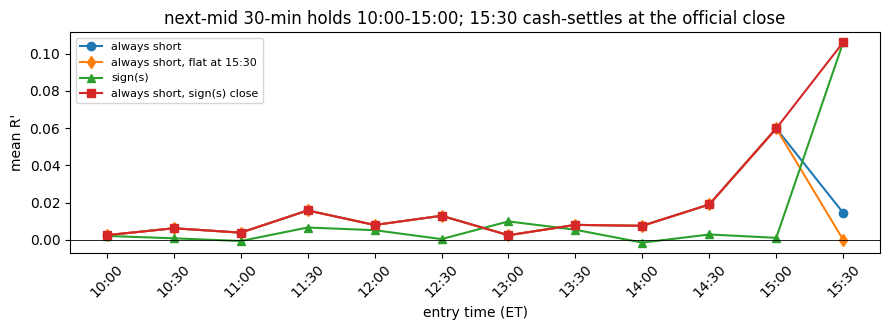

saved CSVs in C:\Users\james\CC Allowed\harxhar-0dte-professor\results\atm_straddle_intraday


In [13]:
clock_rows = []
for hhmm, g in work.groupby("hhmm", sort=True):
    for name, size in q.items():
        rp = (size * work["R"]).loc[g.index]
        st = asl.rule_row(rp, size.loc[g.index])
        clock_rows.append({"hhmm": hhmm, "rule": name, **st.to_dict()})
stab = pd.DataFrame(clock_rows)
stab.to_csv(OUT / "rule_by_entry_hhmm.csv", index=False)
print("always short by clock time")
print(stab[stab["rule"] == "always short"][
    ["hhmm", "n", "mean", "t_mean", "Sharpe_ann"]
].to_string(index=False))
print("sign(s) by clock time (window-matched signal)")
print(stab[stab["rule"] == "sign(s)"][
    ["hhmm", "n", "mean", "t_mean", "Sharpe_ann", "pct_buy"]
].to_string(index=False))

hour_rows = []
for hr, g in work.groupby("hour"):
    for name, size in q.items():
        rp = (size * work["R"]).loc[g.index]
        st = asl.rule_row(rp, size.loc[g.index])
        hour_rows.append({"hour": int(hr), "rule": name, **st.to_dict()})
htab = pd.DataFrame(hour_rows)
htab.to_csv(OUT / "rule_by_entry_hour.csv", index=False)

fig, ax = plt.subplots(figsize=(9, 3.4))
for rule, marker in (("always short", "o"), ("always short, flat at 15:30", "d"),
                     ("sign(s)", "^"), ("always short, sign(s) close", "s")):
    sub = stab[stab["rule"] == rule]
    ax.plot(sub["hhmm"], sub["mean"], marker=marker, label=rule)
ax.axhline(0, color="k", lw=0.6)
ax.set_xlabel("entry time (ET)")
ax.set_ylabel("mean R'")
ax.set_title("next-mid 30-min holds 10:00-15:00; 15:30 cash-settles at the official close")
ax.tick_params(axis="x", rotation=45)
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(OUT / "mean_by_entry_hhmm_as.png", dpi=120, bbox_inches="tight")
display(fig)
plt.close(fig)
print("saved CSVs in", OUT)


## 9. Buy-signal fingerprint (day $\times$ clock)

Each column is one expiration day, each row one 30-min clock. Blue:
the matched signal says **buy** the straddle
($s^{\mathrm{m}}_t>0$ — forecast above the implied slice); red:
short; grey: no signal, so the rule sits flat — the profile's warm-up
or a censored implied volatility. The §8 tables average this grid down
each row; the fingerprint shows the day-resolved structure — whether
buys cluster in episodes (vol spikes), drift across regimes, and how
the buy share thins from the morning rows to the settlement row.

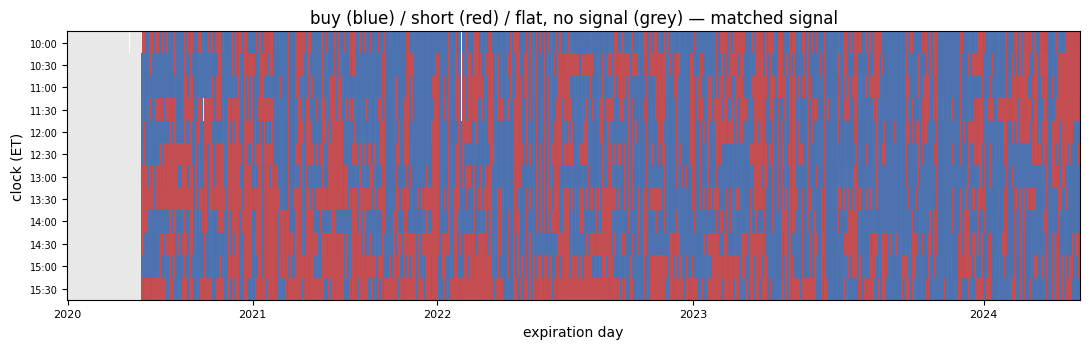

buy share by year (%)
date
2020    28.500000
2021    51.400000
2022    54.500000
2023    63.600000
2024    59.900000


mean same-stance run length within a day (bars): 4.7


In [14]:
grid = work.assign(qsign=pos_m.fillna(0.0)).pivot_table(
    index="hhmm", columns="date", values="qsign", aggfunc="first"
)
grid = grid.sort_index()

from matplotlib.colors import BoundaryNorm, ListedColormap
cmap = ListedColormap(["#c44e52", "#e8e8e8", "#4c72b0"])
norm = BoundaryNorm([-1.5, -0.5, 0.5, 1.5], cmap.N)
fig, ax = plt.subplots(figsize=(11, 3.6))
ax.imshow(grid.to_numpy(), aspect="auto", cmap=cmap, norm=norm, interpolation="none")
ax.set_yticks(range(len(grid.index)), grid.index, fontsize=7)
yrs = pd.DatetimeIndex(grid.columns).year
ticks = [int(np.argmax(yrs == y)) for y in sorted(set(yrs))]
ax.set_xticks(ticks, sorted(set(yrs)), fontsize=8)
ax.set_xlabel("expiration day")
ax.set_ylabel("clock (ET)")
ax.set_title("buy (blue) / short (red) / flat, no signal (grey) — matched signal")
fig.tight_layout()
fig.savefig(OUT / "buy_fingerprint_day_clock.png", dpi=120, bbox_inches="tight")
display(fig)
plt.close(fig)

sgn = pos_m.fillna(0.0)
by_year = work.assign(buy=(sgn > 0)).groupby(work["date"].dt.year)["buy"].mean() * 100.0
print("buy share by year (%)")
print(by_year.round(1).to_string())
runs = (
    work.assign(qsign=sgn)
    .groupby("date")["qsign"]
    .apply(lambda s: (s != s.shift()).cumsum().value_counts().mean())
)
print("mean same-stance run length within a day (bars):", round(float(runs.mean()), 2))
